# Prior Sensitivity in Bayesian Logistic Regression

## 1. Data & EDA

In [2]:
library(MASS)        # Built-in dataset — provides the birthwt dataset
library(rstanarm)    # Bayesian logistic regression via Stan
library(bayesplot)   # Visualizing posterior distributions and predictive checks
library(pROC)        # Computing and comparing ROC curves and AUC
library(ggplot2)     # Custom data visualization
library(dplyr)       # Data manipulation for subsampling experiment
library(tidyr)
data(birthwt)

### Dataset Overview

In [3]:
str(birthwt)

'data.frame':	189 obs. of  10 variables:
 $ low  : int  0 0 0 0 0 0 0 0 0 0 ...
 $ age  : int  19 33 20 21 18 21 22 17 29 26 ...
 $ lwt  : int  182 155 105 108 107 124 118 103 123 113 ...
 $ race : int  2 3 1 1 1 3 1 3 1 1 ...
 $ smoke: int  0 0 1 1 1 0 0 0 1 1 ...
 $ ptl  : int  0 0 0 0 0 0 0 0 0 0 ...
 $ ht   : int  0 0 0 0 0 0 0 0 0 0 ...
 $ ui   : int  1 0 0 1 1 0 0 0 0 0 ...
 $ ftv  : int  0 3 1 2 0 0 1 1 1 0 ...
 $ bwt  : int  2523 2551 2557 2594 2600 2622 2637 2637 2663 2665 ...


In [4]:
birthwt$race  <- as.factor(birthwt$race)
birthwt$smoke <- as.factor(birthwt$smoke)
birthwt$ht    <- as.factor(birthwt$ht)
birthwt$ui    <- as.factor(birthwt$ui)

summary(birthwt)

      low              age             lwt        race   smoke  
 Min.   :0.0000   Min.   :14.00   Min.   : 80.0   1:96   0:115  
 1st Qu.:0.0000   1st Qu.:19.00   1st Qu.:110.0   2:26   1: 74  
 Median :0.0000   Median :23.00   Median :121.0   3:67          
 Mean   :0.3122   Mean   :23.24   Mean   :129.8                 
 3rd Qu.:1.0000   3rd Qu.:26.00   3rd Qu.:140.0                 
 Max.   :1.0000   Max.   :45.00   Max.   :250.0                 
      ptl         ht      ui           ftv              bwt      
 Min.   :0.0000   0:177   0:161   Min.   :0.0000   Min.   : 709  
 1st Qu.:0.0000   1: 12   1: 28   1st Qu.:0.0000   1st Qu.:2414  
 Median :0.0000                   Median :0.0000   Median :2977  
 Mean   :0.1958                   Mean   :0.7937   Mean   :2945  
 3rd Qu.:0.0000                   3rd Qu.:1.0000   3rd Qu.:3487  
 Max.   :3.0000                   Max.   :6.0000   Max.   :4990  

In [5]:
sum(is.na(birthwt))

table(birthwt$low)

[1] 0


  0   1 
130  59 

### Feature Description

#### Class balance

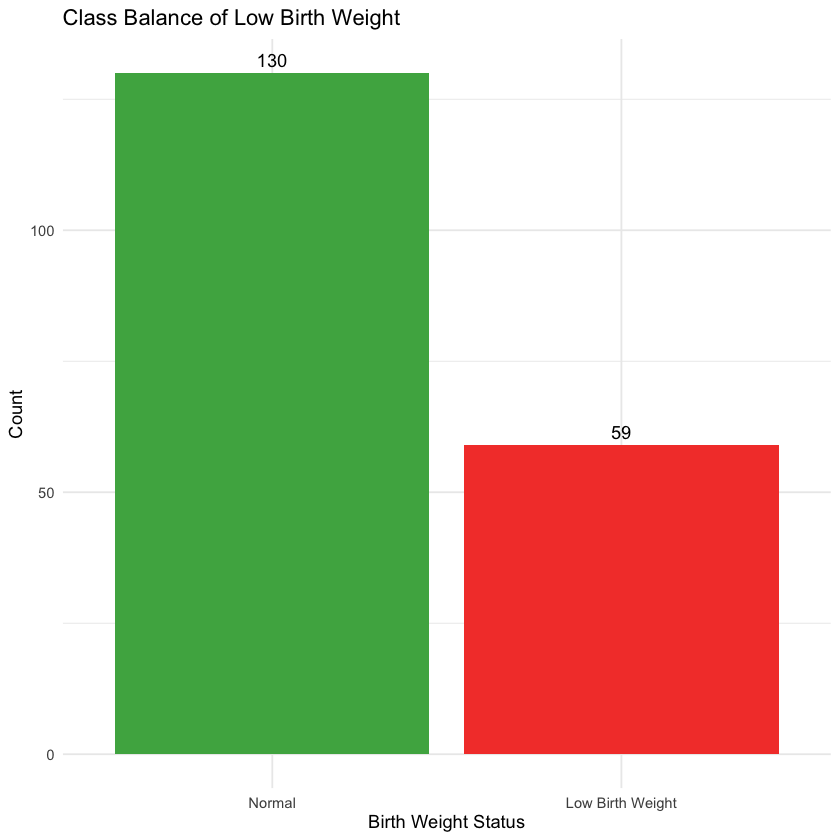

In [6]:
ggplot(data = birthwt, aes(x = factor(low, labels = c("Normal", "Low Birth Weight")))) +
  geom_bar(fill = c("#4CAF50", "#F44336")) +
  geom_text(stat = "count", aes(label = after_stat(count)), vjust = -0.5) +
  labs(title = "Class Balance of Low Birth Weight",
       x = "Birth Weight Status",
       y = "Count") +
  theme_minimal()

#### Continuous features

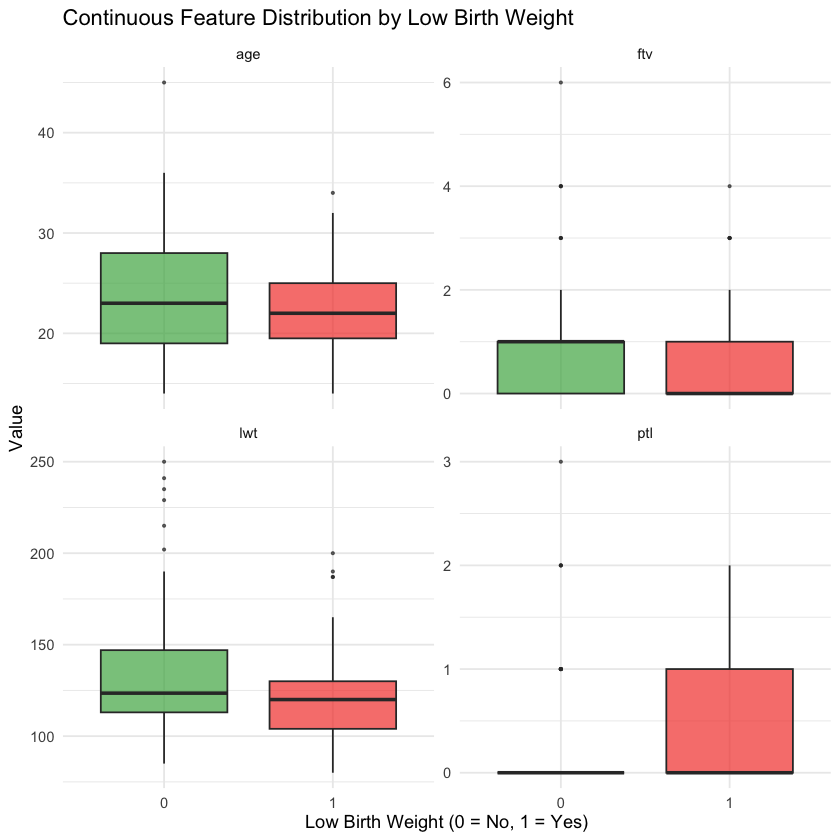

In [7]:
features <- c("age", "lwt", "ptl", "ftv")

df.long <- pivot_longer(birthwt[, c("low", features)],
                        cols = -low,
                        names_to = "feature",
                        values_to = "value")

ggplot(data = df.long, aes(x = factor(low), y = value, fill = factor(low))) +
  geom_boxplot(outlier.size = 0.5, alpha = 0.7) +
  facet_wrap(~ feature, scales = "free_y", ncol = 2) +
  scale_fill_manual(values = c("0" = "#4CAF50", "1" = "#F44336")) +
  labs(title = "Continuous Feature Distribution by Low Birth Weight",
       x = "Low Birth Weight (0 = No, 1 = Yes)", 
       y = "Value") +
  theme_minimal() +
  theme(legend.position = "none")

#### Categorical features

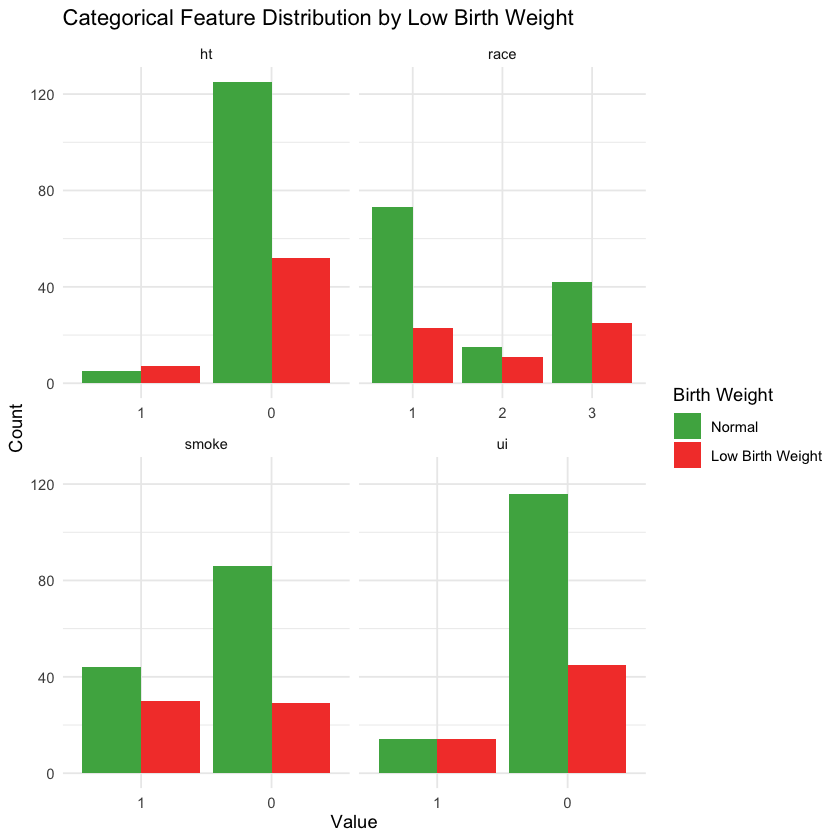

In [8]:
features.cat <- c("race", "smoke", "ht", "ui")

df.cat <- pivot_longer(birthwt[, c("low", features.cat)],
                       cols = -low,
                       names_to = "feature",
                       values_to = "value")

ggplot(data = df.cat, aes(x = factor(value), fill = factor(low))) +
  geom_bar(position = "dodge") +
  facet_wrap(~ feature, scales = "free_x", ncol = 2) +
  scale_fill_manual(values = c("0" = "#4CAF50", "1" = "#F44336"),
                    labels = c("Normal", "Low Birth Weight")) +
  labs(title = "Categorical Feature Distribution by Low Birth Weight",
       x = "Value",
       y = "Count",
       fill = "Birth Weight") +
  theme_minimal()

#### Feature Correlation

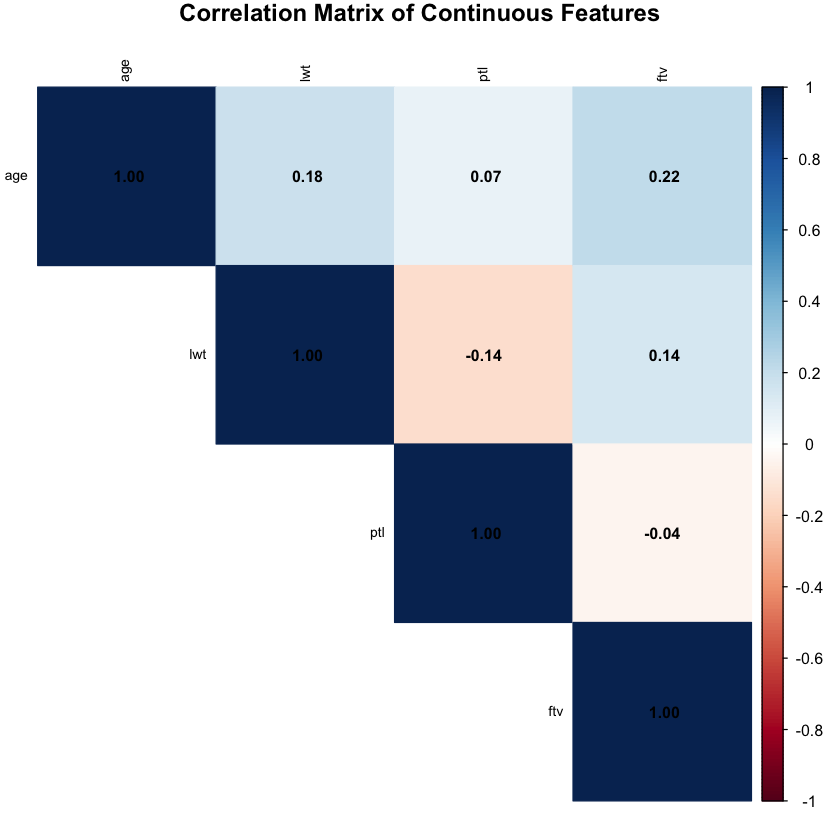

In [9]:
features.only <- birthwt[, c("age", "lwt", "ptl", "ftv")]
corr.matrix   <- cor(features.only)

corrplot::corrplot(corr.matrix,
                   method     = "color",
                   type       = "upper",
                   tl.cex     = 0.7,
                   tl.col     = "black",
                   addCoef.col = "black",
                   number.cex = 0.8,
                   title      = "Correlation Matrix of Continuous Features",
                   mar        = c(0, 0, 1, 0))

## 2. Helper Functions

In [10]:
run_stan_glm <- function(data, prior, prior_int) {
  stan_glm(
    low ~ age + lwt + race + smoke + ptl + ht + ui + ftv,
    data            = data,
    family          = binomial(link = "logit"),
    prior           = prior,
    prior_intercept = prior_int,
    seed            = 42,
    refresh         = 0
  )
}

In [11]:
get_posterior_summary <- function(fit, model_name) {
  ps <- as.data.frame(fit$stan_summary)
  ps <- ps[!rownames(ps) %in% c("mean_PPD", "log-posterior"), ]
  data.frame(
    Model    = model_name,
    Variable = rownames(ps),
    Mean     = round(ps$mean, 3),
    CI_2.5   = round(ps$`2.5%`, 3),
    CI_97.5  = round(ps$`97.5%`, 3),
    OR       = round(exp(ps$mean), 3)
  )
}

In [12]:
get_auc <- function(fit, data) {
  pred      <- colMeans(posterior_epred(fit))
  roc.obj   <- roc(data$low, pred, quiet = TRUE)
  as.numeric(auc(roc.obj))
}

In [13]:
loo_safe <- function(fit) {
  tryCatch({
    l      <- suppressWarnings(loo(fit))
    looic  <- l$estimates["looic", "Estimate"]
    k_warn <- sum(l$diagnostics$pareto_k > 0.7)
    list(looic = round(looic, 3), k_warn = k_warn)
  }, error = function(e) list(looic = NA, k_warn = NA))
}

# Analysis 1: Prior Sensitivity (Full Data, n = 189)

## Prior Specification

### Diffuse Prior — N(0, 100)

In [14]:
prior.diffuse <- normal(0, 100)
prior_int.diffuse <- normal(0, 100)
fit.diffuse <- run_stan_glm(birthwt, prior.diffuse, prior_int.diffuse)

### Weakly Informative Prior — N(0, 2.5)

In [15]:
prior.weak        <- normal(0, 2.5)
prior_int.weak    <- normal(0, 10)
fit.weak          <- run_stan_glm(birthwt, prior.weak, prior_int.weak)

### Clinically Informative Prior

In [16]:
prior.informative <- normal(
  location = c(0,    # age
               0,    # lwt
               0,    # race2
               0,    # race3
               1,    # smoke1
               0,    # ptl
               1,    # ht1
               0,    # ui1
               0),   # ftv
  scale    = c(1,    # age
               1,    # lwt
               1,    # race2
               1,    # race3
               0.5,  # smoke1
               1,    # ptl
               0.5,  # ht1
               1,    # ui1
               1)    # ftv
)
prior_int.informative <- normal(0, 5)
fit.informative       <- run_stan_glm(birthwt, prior.informative, prior_int.informative)

## MCMC Diagnostics

### Trace Plots

#### Diffuse Prior — N(0, 100)

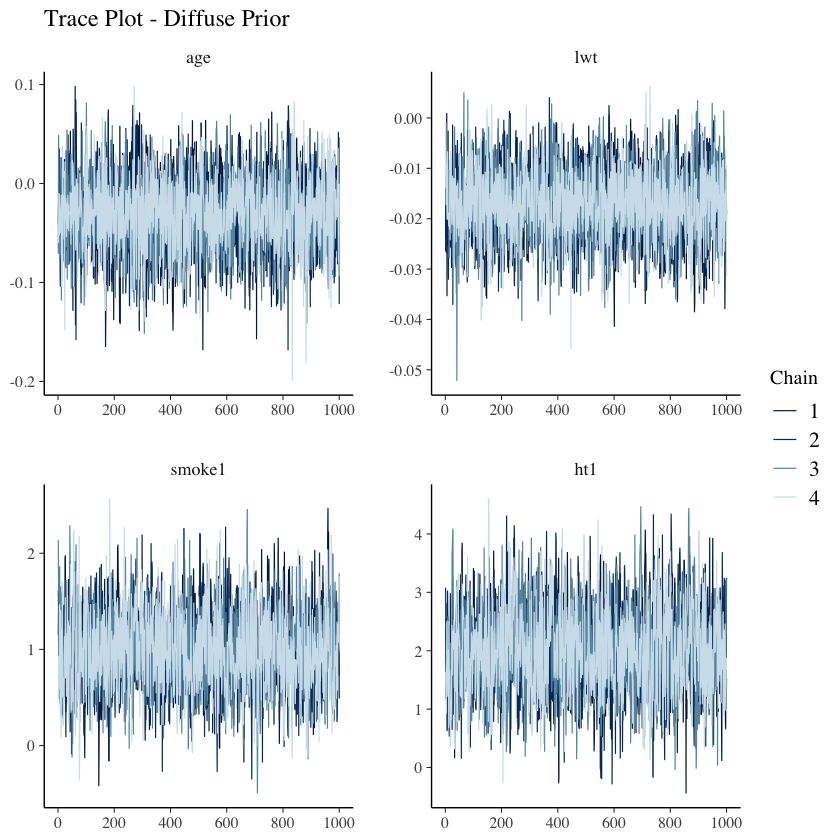

In [17]:
mcmc_trace(as.array(fit.diffuse),
           pars = c("age", "lwt", "smoke1", "ht1")) +
  ggtitle("Trace Plot - Diffuse Prior")

#### Weakly Informative Prior — N(0, 2.5)

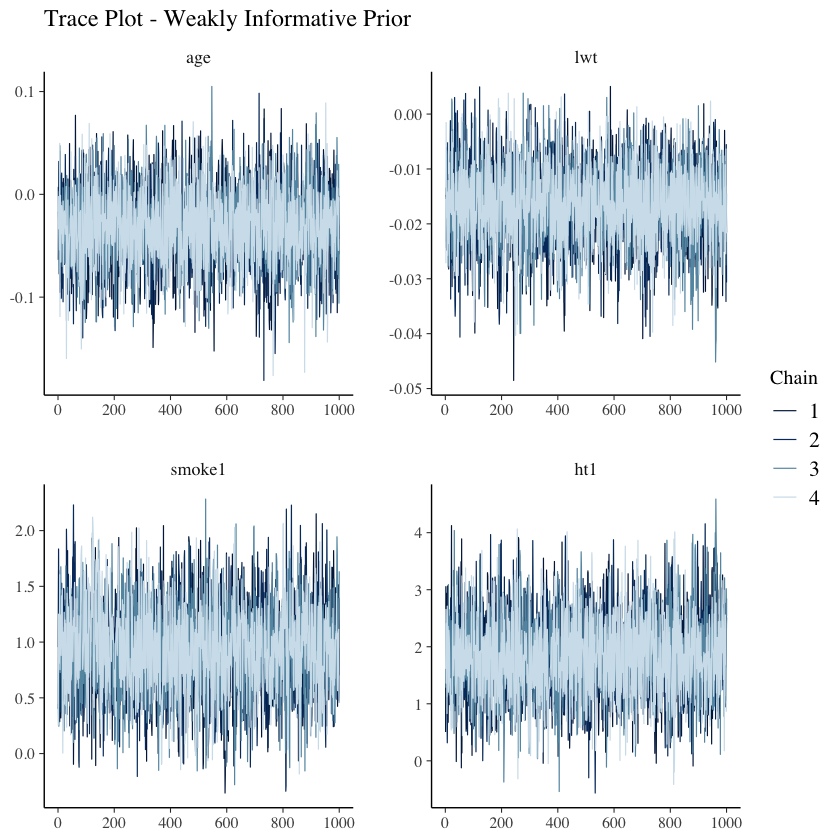

In [18]:
mcmc_trace(as.array(fit.weak),
           pars = c("age", "lwt", "smoke1", "ht1")) +
  ggtitle("Trace Plot - Weakly Informative Prior")

#### Clinically Informative Prior

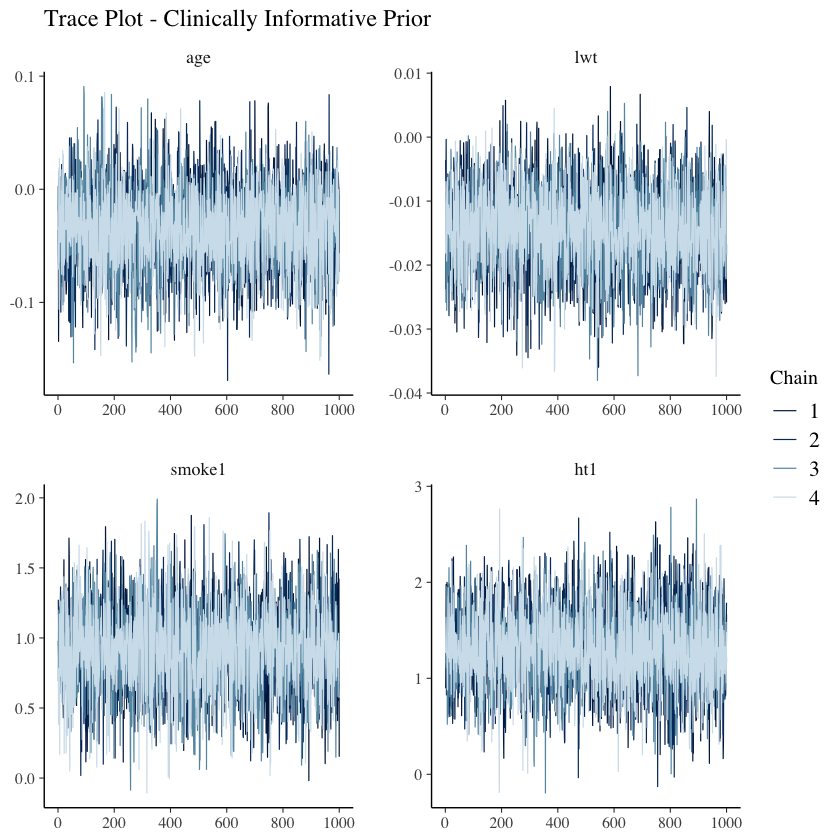

In [19]:
mcmc_trace(as.array(fit.informative),
           pars = c("age", "lwt", "smoke1", "ht1")) +
  ggtitle("Trace Plot - Clinically Informative Prior")

### Rhat Convergence Summary

In [20]:
result.rhat <- data.frame(
  Variable    = rownames(fit.diffuse$stan_summary),
  Rhat_Diffuse     = round(fit.diffuse$stan_summary[, "Rhat"], 3),
  Rhat_Weak        = round(fit.weak$stan_summary[, "Rhat"], 3),
  Rhat_Informative = round(fit.informative$stan_summary[, "Rhat"], 3)
)
print(result.rhat, row.names = FALSE)

      Variable Rhat_Diffuse Rhat_Weak Rhat_Informative
   (Intercept)        1.000     0.999            1.000
           age        1.000     1.000            1.000
           lwt        0.999     0.999            1.001
         race2        1.001     1.000            0.999
         race3        0.999     1.000            1.001
        smoke1        1.000     1.000            1.000
           ptl        1.000     1.000            1.002
           ht1        1.000     1.000            1.001
           ui1        1.000     1.000            1.000
           ftv        0.999     1.000            0.999
      mean_PPD        1.000     1.000            0.999
 log-posterior        1.000     1.001            1.001


## Posterior Summary

### Coefficient Estimates

In [21]:
print(fit.diffuse, digits = 3)

stan_glm
 family:       binomial [logit]
 formula:      low ~ age + lwt + race + smoke + ptl + ht + ui + ftv
 observations: 189
 predictors:   10
------
            Median MAD_SD
(Intercept)  0.580  1.231
age         -0.030  0.038
lwt         -0.017  0.007
race2        1.349  0.541
race3        0.928  0.451
smoke1       0.983  0.417
ptl          0.580  0.351
ht1          1.994  0.730
ui1          0.803  0.461
ftv          0.056  0.183

------
* For help interpreting the printed output see ?print.stanreg
* For info on the priors used see ?prior_summary.stanreg


In [22]:
print(fit.weak, digits = 3)

stan_glm
 family:       binomial [logit]
 formula:      low ~ age + lwt + race + smoke + ptl + ht + ui + ftv
 observations: 189
 predictors:   10
------
            Median MAD_SD
(Intercept)  0.676  1.215
age         -0.031  0.038
lwt         -0.016  0.007
race2        1.250  0.513
race3        0.853  0.435
smoke1       0.933  0.403
ptl          0.572  0.356
ht1          1.827  0.739
ui1          0.760  0.463
ftv          0.048  0.177

------
* For help interpreting the printed output see ?print.stanreg
* For info on the priors used see ?prior_summary.stanreg


In [23]:
print(fit.informative, digits = 3)

stan_glm
 family:       binomial [logit]
 formula:      low ~ age + lwt + race + smoke + ptl + ht + ui + ftv
 observations: 189
 predictors:   10
------
            Median MAD_SD
(Intercept)  0.622  1.106
age         -0.033  0.037
lwt         -0.014  0.006
race2        0.966  0.464
race3        0.706  0.378
smoke1       0.915  0.302
ptl          0.538  0.334
ht1          1.311  0.408
ui1          0.624  0.445
ftv          0.030  0.168

------
* For help interpreting the printed output see ?print.stanreg
* For info on the priors used see ?prior_summary.stanreg


### Coefficient Estimates Across Priors

In [24]:
result.coef.compare <- data.frame(
  Variable    = names(coef(fit.diffuse)),
  Diffuse     = round(coef(fit.diffuse), 3),
  Weak        = round(coef(fit.weak), 3),
  Informative = round(coef(fit.informative), 3)
)
print(result.coef.compare, row.names = FALSE)

    Variable Diffuse   Weak Informative
 (Intercept)   0.580  0.676       0.622
         age  -0.030 -0.031      -0.033
         lwt  -0.017 -0.016      -0.014
       race2   1.349  1.250       0.966
       race3   0.928  0.853       0.706
      smoke1   0.983  0.933       0.915
         ptl   0.580  0.572       0.538
         ht1   1.994  1.827       1.311
         ui1   0.803  0.760       0.624
         ftv   0.056  0.048       0.030


In [25]:
result.posterior <- rbind(
  get_posterior_summary(fit.diffuse,     "Diffuse"),
  get_posterior_summary(fit.weak,        "Weak"),
  get_posterior_summary(fit.informative, "Informative")
)
print(result.posterior, row.names = FALSE)

       Model    Variable   Mean CI_2.5 CI_97.5    OR
     Diffuse (Intercept)  0.609 -1.755   3.140 1.839
     Diffuse         age -0.031 -0.106   0.044 0.970
     Diffuse         lwt -0.017 -0.032  -0.003 0.983
     Diffuse       race2  1.349  0.315   2.421 3.853
     Diffuse       race3  0.930  0.023   1.812 2.534
     Diffuse      smoke1  0.994  0.209   1.827 2.702
     Diffuse         ptl  0.582 -0.094   1.283 1.790
     Diffuse         ht1  2.002  0.630   3.495 7.402
     Diffuse         ui1  0.792 -0.146   1.684 2.208
     Diffuse         ftv  0.054 -0.314   0.392 1.055
        Weak (Intercept)  0.654 -1.739   3.037 1.923
        Weak         age -0.031 -0.107   0.043 0.969
        Weak         lwt -0.017 -0.032  -0.003 0.984
        Weak       race2  1.248  0.243   2.279 3.485
        Weak       race3  0.860  0.010   1.729 2.363
        Weak      smoke1  0.929  0.129   1.739 2.531
        Weak         ptl  0.577 -0.101   1.290 1.780
        Weak         ht1  1.840  0.490   3.303

### Coefficient Plot  

#### Continuous Predictors

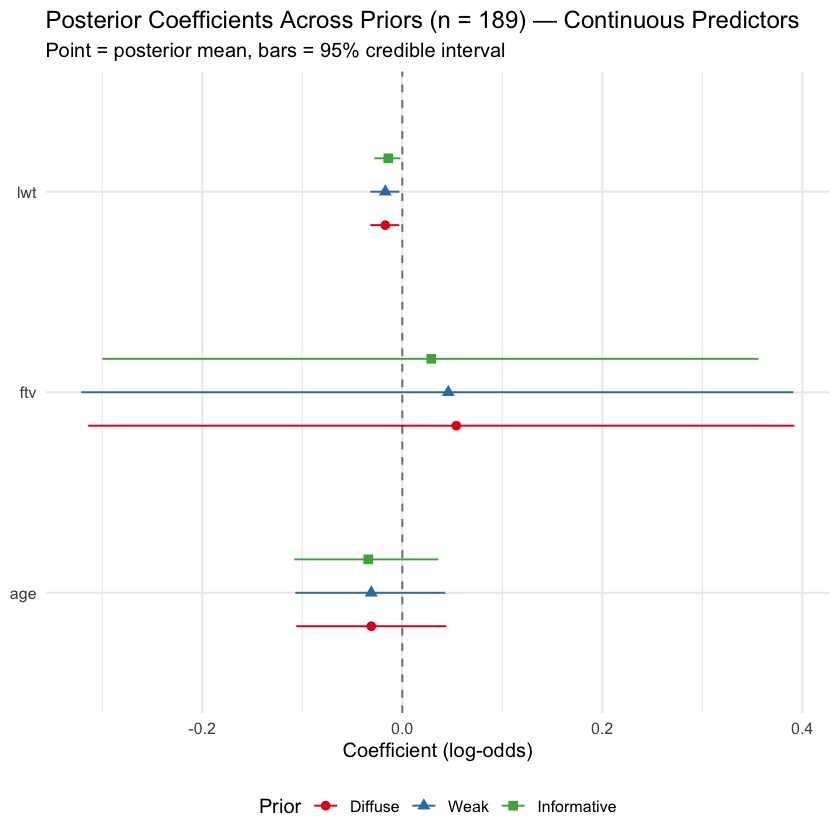

In [26]:
df.plot <- result.posterior[result.posterior$Variable != "(Intercept)", ]
df.plot$Model <- factor(df.plot$Model, levels = c("Diffuse", "Weak", "Informative"))

vars.continuous <- c("age", "lwt", "ftv")
df.continuous <- df.plot[df.plot$Variable %in% vars.continuous, ]

ggplot(df.continuous, aes(x = Mean, y = Variable, color = Model, shape = Model)) +
  geom_vline(xintercept = 0, linetype = "dashed", color = "grey50") +
  geom_pointrange(aes(xmin = CI_2.5, xmax = CI_97.5),
                  position = position_dodge(width = 0.5),
                  size = 0.5) +
  scale_color_manual(values = c("Diffuse"     = "#E41A1C",
                                "Weak"        = "#377EB8",
                                "Informative" = "#4DAF4A")) +
  scale_shape_manual(values = c("Diffuse" = 16, "Weak" = 17, "Informative" = 15)) +
  labs(title    = "Posterior Coefficients Across Priors (n = 189) — Continuous Predictors",
       subtitle = "Point = posterior mean, bars = 95% credible interval",
       x = "Coefficient (log-odds)", y = NULL,
       color = "Prior", shape = "Prior") +
  theme_minimal(base_size = 12) +
  theme(legend.position = "bottom")

#### Categorical / Binary Predictors

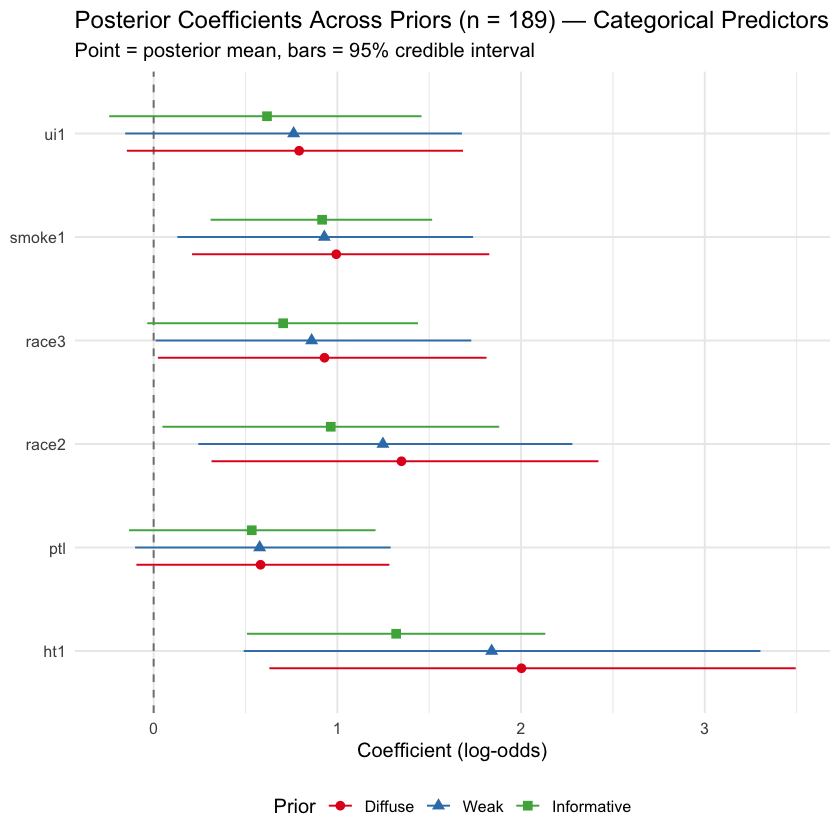

In [43]:
vars.binary <- c("race2", "race3", "smoke1", "ptl", "ht1", "ui1")
df.binary <- df.plot[df.plot$Variable %in% vars.binary, ]

ggplot(df.binary, aes(x = Mean, y = Variable, color = Model, shape = Model)) +
  geom_vline(xintercept = 0, linetype = "dashed", color = "grey50") +
  geom_pointrange(aes(xmin = CI_2.5, xmax = CI_97.5),
                  position = position_dodge(width = 0.5),
                  size = 0.5) +
  scale_color_manual(values = c("Diffuse"     = "#E41A1C",
                                "Weak"        = "#377EB8",
                                "Informative" = "#4DAF4A")) +
  scale_shape_manual(values = c("Diffuse" = 16, "Weak" = 17, "Informative" = 15)) +
  labs(title    = "Posterior Coefficients Across Priors (n = 189) — Categorical Predictors",
       subtitle = "Point = posterior mean, bars = 95% credible interval",
       x = "Coefficient (log-odds)", y = NULL,
       color = "Prior", shape = "Prior") +
  theme_minimal(base_size = 12) +
  theme(legend.position = "bottom")

### LOO Model Comparison

In [28]:
loo.diffuse     <- loo(fit.diffuse)
loo.weak        <- loo(fit.weak)
loo.informative <- loo(fit.informative)

loo.compare <- loo_compare(loo.diffuse, loo.weak, loo.informative)

result.loo <- data.frame(
  Model    = rownames(loo.compare),
  elpd_loo = round(loo.compare[, "elpd_loo"], 2),
  p_loo    = round(loo.compare[, "p_loo"], 2),
  looic    = round(loo.compare[, "looic"], 2)
)
print(result.loo, row.names = FALSE)

           Model elpd_loo p_loo  looic
 fit.informative  -110.21  8.99 220.43
        fit.weak  -111.66 11.01 223.32
     fit.diffuse  -111.92 11.28 223.85


### AUC Comparison

In [29]:
result.auc <- data.frame(
  Model = c("Diffuse", "Weak", "Informative"),
  AUC   = round(c(
    get_auc(fit.diffuse,     birthwt),
    get_auc(fit.weak,        birthwt),
    get_auc(fit.informative, birthwt)
  ), 3)
)
print(result.auc, row.names = FALSE)

       Model   AUC
     Diffuse 0.746
        Weak 0.747
 Informative 0.748


# Analysis 2: Subsampling Experiment

## Fit Models Across Sample Sizes

In [30]:
sample.sizes <- c(20, 40, 80, 189)
results.sub  <- list()
auc.list     <- list()

for (n in sample.sizes) {
  set.seed(42)
  data.sub <- if (n < 189) birthwt[sample(nrow(birthwt), n), ] else birthwt

  fit.sub.diffuse     <- run_stan_glm(data.sub, prior.diffuse,     prior_int.diffuse)
  fit.sub.weak        <- run_stan_glm(data.sub, prior.weak,        prior_int.weak)
  fit.sub.informative <- run_stan_glm(data.sub, prior.informative, prior_int.informative)

  # Analysis 2：posterior summary
  results.sub[[as.character(n)]] <- rbind(
    get_posterior_summary(fit.sub.diffuse,     "Diffuse"),
    get_posterior_summary(fit.sub.weak,        "Weak"),
    get_posterior_summary(fit.sub.informative, "Informative")
  )

  # Analysis 3：AUC + LOO
  auc.list[[as.character(n)]] <- data.frame(
    n      = n,
    Model  = c("Diffuse", "Weak", "Informative"),
    AUC    = round(c(
      get_auc(fit.sub.diffuse,     data.sub),
      get_auc(fit.sub.weak,        data.sub),
      get_auc(fit.sub.informative, data.sub)
    ), 3),
    LOOIC  = c(
      loo_safe(fit.sub.diffuse)$looic,
      loo_safe(fit.sub.weak)$looic,
      loo_safe(fit.sub.informative)$looic
    ),
    k_warn = c(
      loo_safe(fit.sub.diffuse)$k_warn,
      loo_safe(fit.sub.weak)$k_warn,
      loo_safe(fit.sub.informative)$k_warn
    )
  )
  # Save models for app
  saveRDS(fit.sub.diffuse,     paste0("../models/fit_diffuse_n",     n, ".rds"))
  saveRDS(fit.sub.weak,        paste0("../models/fit_weak_n",        n, ".rds"))
  saveRDS(fit.sub.informative, paste0("../models/fit_informative_n", n, ".rds"))

  cat("Done: n =", n, "\n")
}

df.sub <- do.call(rbind, lapply(names(results.sub), function(n) {
  df <- results.sub[[n]]; df$n <- as.integer(n); df
}))

df.auc <- do.call(rbind, auc.list)

Done: n = 20 
Done: n = 40 
Done: n = 80 
Done: n = 189 


## Coefficient Convergence: smoke1 & ui1 & ht1

In [31]:
print(df.sub[df.sub$Variable %in% c("smoke1", "ui1", "ht1"), 
             c("n", "Model", "Variable", "Mean", "CI_2.5", "CI_97.5")], 
      row.names = FALSE)

   n       Model Variable    Mean  CI_2.5 CI_97.5
  20     Diffuse   smoke1 203.164 103.132 325.195
  20     Diffuse      ht1 108.951  21.410 242.219
  20     Diffuse      ui1 115.663  44.094 210.000
  20        Weak   smoke1   4.311   1.026   7.982
  20        Weak      ht1   1.318  -2.703   5.458
  20        Weak      ui1   2.501  -0.862   6.082
  20 Informative   smoke1   1.349   0.408   2.290
  20 Informative      ht1   1.101   0.170   2.008
  20 Informative      ui1   0.764  -0.975   2.491
  40     Diffuse   smoke1   1.281  -1.580   4.476
  40     Diffuse      ht1  82.426   6.158 221.356
  40     Diffuse      ui1   1.903  -0.645   4.801
  40        Weak   smoke1   0.633  -1.464   2.762
  40        Weak      ht1   2.428  -1.351   6.304
  40        Weak      ui1   1.408  -0.717   3.718
  40 Informative   smoke1   0.821  -0.040   1.705
  40 Informative      ht1   1.126   0.183   2.060
  40 Informative      ui1   0.655  -0.806   2.123
  80     Diffuse   smoke1   1.136  -0.290   2.757


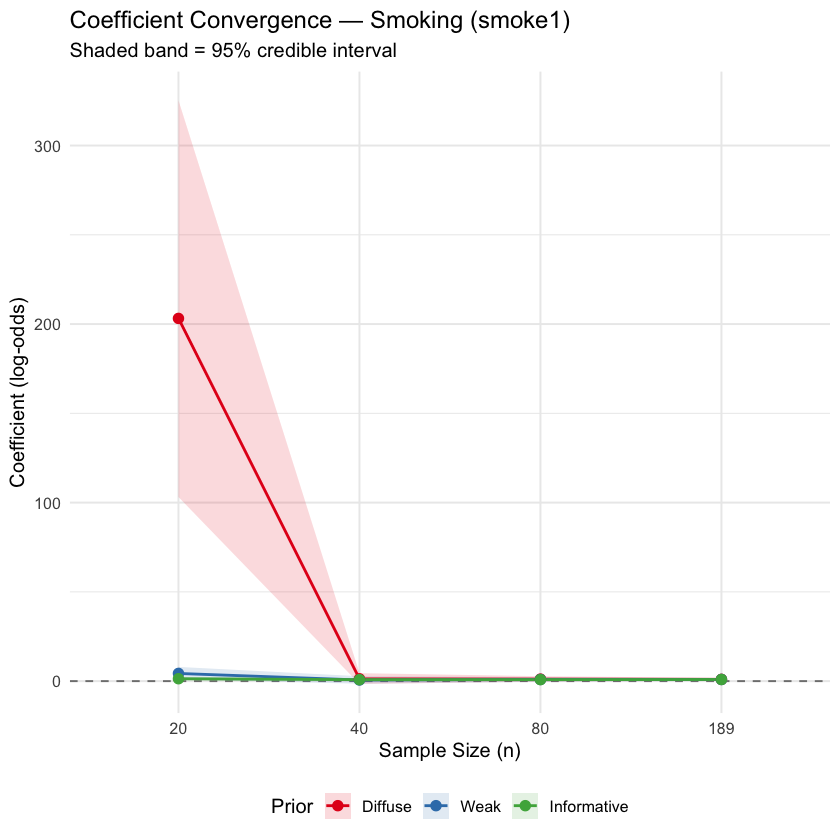

In [32]:
df.smoke <- df.sub[df.sub$Variable == "smoke1", ]
df.smoke$Model <- factor(df.smoke$Model, levels = c("Diffuse", "Weak", "Informative"))
df.smoke$n     <- factor(df.smoke$n, levels = c(20, 40, 80, 189))

ggplot(df.smoke, aes(x = n, y = Mean, color = Model, group = Model)) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "grey50") +
  geom_ribbon(aes(ymin = CI_2.5, ymax = CI_97.5, fill = Model),
              alpha = 0.15, color = NA) +
  geom_line(linewidth = 0.8) +
  geom_point(size = 2.5) +
  scale_color_manual(values = c("Diffuse"     = "#E41A1C",
                                "Weak"        = "#377EB8",
                                "Informative" = "#4DAF4A")) +
  scale_fill_manual(values  = c("Diffuse"     = "#E41A1C",
                                "Weak"        = "#377EB8",
                                "Informative" = "#4DAF4A")) +
  labs(title    = "Coefficient Convergence — Smoking (smoke1)",
       subtitle = "Shaded band = 95% credible interval",
       x = "Sample Size (n)", y = "Coefficient (log-odds)",
       color = "Prior", fill = "Prior") +
  theme_minimal(base_size = 12) +
  theme(legend.position = "bottom")

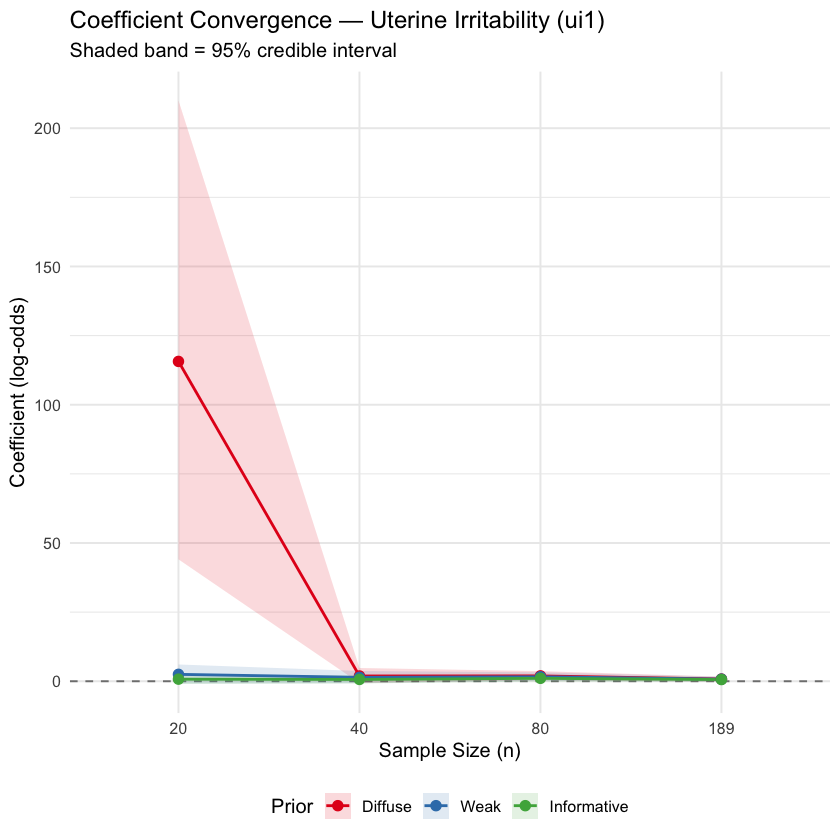

In [33]:
df.ui <- df.sub[df.sub$Variable == "ui1", ]
df.ui$Model <- factor(df.ui$Model, levels = c("Diffuse", "Weak", "Informative"))
df.ui$n     <- factor(df.ui$n, levels = c(20, 40, 80, 189))

ggplot(df.ui, aes(x = n, y = Mean, color = Model, group = Model)) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "grey50") +
  geom_ribbon(aes(ymin = CI_2.5, ymax = CI_97.5, fill = Model),
              alpha = 0.15, color = NA) +
  geom_line(linewidth = 0.8) +
  geom_point(size = 2.5) +
  scale_color_manual(values = c("Diffuse"     = "#E41A1C",
                                "Weak"        = "#377EB8",
                                "Informative" = "#4DAF4A")) +
  scale_fill_manual(values  = c("Diffuse"     = "#E41A1C",
                                "Weak"        = "#377EB8",
                                "Informative" = "#4DAF4A")) +
  labs(title    = "Coefficient Convergence — Uterine Irritability (ui1)",
       subtitle = "Shaded band = 95% credible interval",
       x = "Sample Size (n)", y = "Coefficient (log-odds)",
       color = "Prior", fill = "Prior") +
  theme_minimal(base_size = 12) +
  theme(legend.position = "bottom")

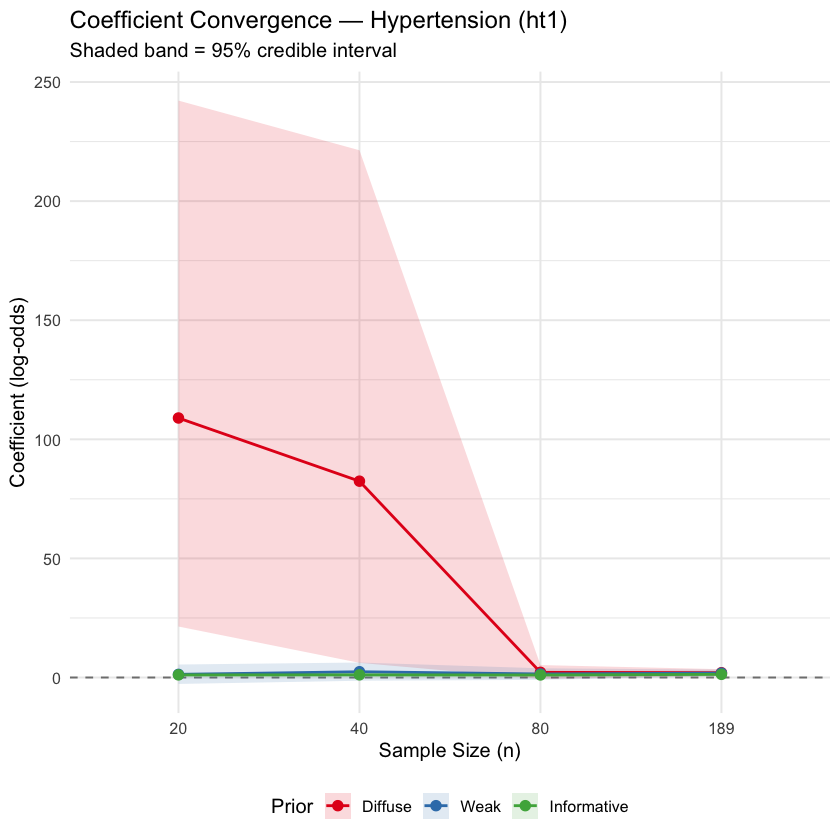

In [34]:
df.ht <- df.sub[df.sub$Variable == "ht1", ]
df.ht$Model <- factor(df.ht$Model, levels = c("Diffuse", "Weak", "Informative"))
df.ht$n     <- factor(df.ht$n, levels = c(20, 40, 80, 189))

ggplot(df.ht, aes(x = n, y = Mean, color = Model, group = Model)) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "grey50") +
  geom_ribbon(aes(ymin = CI_2.5, ymax = CI_97.5, fill = Model),
              alpha = 0.15, color = NA) +
  geom_line(linewidth = 0.8) +
  geom_point(size = 2.5) +
  scale_color_manual(values = c("Diffuse"     = "#E41A1C",
                                "Weak"        = "#377EB8",
                                "Informative" = "#4DAF4A")) +
  scale_fill_manual(values  = c("Diffuse"     = "#E41A1C",
                                "Weak"        = "#377EB8",
                                "Informative" = "#4DAF4A")) +
  labs(title    = "Coefficient Convergence — Hypertension (ht1)",
       subtitle = "Shaded band = 95% credible interval",
       x = "Sample Size (n)", y = "Coefficient (log-odds)",
       color = "Prior", fill = "Prior") +
  theme_minimal(base_size = 12) +
  theme(legend.position = "bottom")

## Robustness Check: Repeated Subsampling

In [35]:
R             <- 100
sub.sizes.rep <- c(20, 40, 80)
track.vars    <- c("smoke1", "ui1", "ht1")
explode.cut   <- 10

build_formula <- function(data) {
  terms_all <- c("age","lwt","race","smoke","ptl","ht","ui","ftv")
  keep <- sapply(terms_all, function(v) {
    x <- data[[v]]
    if (is.factor(x)) nlevels(droplevels(x)) >= 2 else length(unique(x)) >= 2
  })
  reformulate(terms_all[keep], response = "low")
}

make_diffuse <- function(form, data) {
  nm <- colnames(model.matrix(form, data))
  nm <- nm[nm != "(Intercept)"]
  normal(location = rep(0, length(nm)), scale = rep(10, length(nm)))
}

make_weak <- function(form, data) {
  nm <- colnames(model.matrix(form, data))
  nm <- nm[nm != "(Intercept)"]
  normal(location = rep(0, length(nm)), scale = rep(2.5, length(nm)))
}

make_informative <- function(form, data) {
  nm <- colnames(model.matrix(form, data))
  nm <- nm[nm != "(Intercept)"]
  normal(location = ifelse(nm %in% c("smoke1","ht1"), 1, 0),
         scale    = ifelse(nm %in% c("smoke1","ht1"), 0.5, 1))
}
prior_int.shared <- normal(0, 10)

fit_one <- function(data, form, prior, prior_int) {
  stan_glm(form, data = data, family = binomial("logit"),
           prior = prior, prior_intercept = prior_int,
           seed = 42, refresh = 0)
}

rep.rows <- list(); k <- 0

for (n in sub.sizes.rep) {
  for (r in seq_len(R)) {
    set.seed(n * 1000 + r)
    data.sub <- droplevels(birthwt[sample(nrow(birthwt), n), , drop = FALSE])
    form     <- build_formula(data.sub)

    fits <- list(
      Diffuse     = tryCatch(
        fit_one(data.sub, form, make_diffuse(form, data.sub),     prior_int.shared),
        error = function(e) NULL),
      Weak        = tryCatch(
        fit_one(data.sub, form, make_weak(form, data.sub),        prior_int.shared),
        error = function(e) NULL),
      Informative = tryCatch(
        fit_one(data.sub, form, make_informative(form, data.sub), prior_int.shared),
        error = function(e) NULL)
    )

    for (mdl in names(fits)) {
      for (v in track.vars) {
        k   <- k + 1
        fit <- fits[[mdl]]
        defined <- !is.null(fit) && (v %in% names(coef(fit)))
        m   <- if (defined) as.numeric(coef(fit)[v]) else NA_real_
        rep.rows[[k]] <- data.frame(
          n        = n,
          rep      = r,
          Model    = mdl,
          Variable = v,
          Mean     = m,
          defined  = defined,
          exploded = isTRUE(abs(m) > explode.cut)
        )
      }
    }
  }
  cat("Done repeated subsampling: n =", n, "\n")
}

df.rep <- do.call(rbind, rep.rows)
saveRDS(df.rep, "../models/df_rep.rds")

Done repeated subsampling: n = 20 
Done repeated subsampling: n = 40 
Done repeated subsampling: n = 80 


In [36]:
df.rep %>%
  group_by(n, Model, Variable) %>%
  summarise(
    pct_undef   = round(100 * mean(!defined), 1),
    pct_explode = round(100 * mean(exploded[defined], na.rm = TRUE), 1),  # ← 只看 defined
    median_mean = round(median(Mean[defined & !exploded], na.rm = TRUE), 2),
    .groups = "drop"
  ) %>%
  filter(Model == "Diffuse") %>% arrange(Variable, n) %>% print(n = Inf)

# A tibble: 9 × 6
      n Model   Variable pct_undef pct_explode median_mean
  <dbl> <chr>   <chr>        <dbl>       <dbl>       <dbl>
1    20 Diffuse ht1             26        31.1        0.89
2    40 Diffuse ht1              9        17.6        3.5 
3    80 Diffuse ht1              0         0          2.51
4    20 Diffuse smoke1           0        13          1.92
5    40 Diffuse smoke1           0         1          1.27
6    80 Diffuse smoke1           0         0          1.02
7    20 Diffuse ui1              3        17.5        1.28
8    40 Diffuse ui1              0         3          1.92
9    80 Diffuse ui1              0         1          0.88


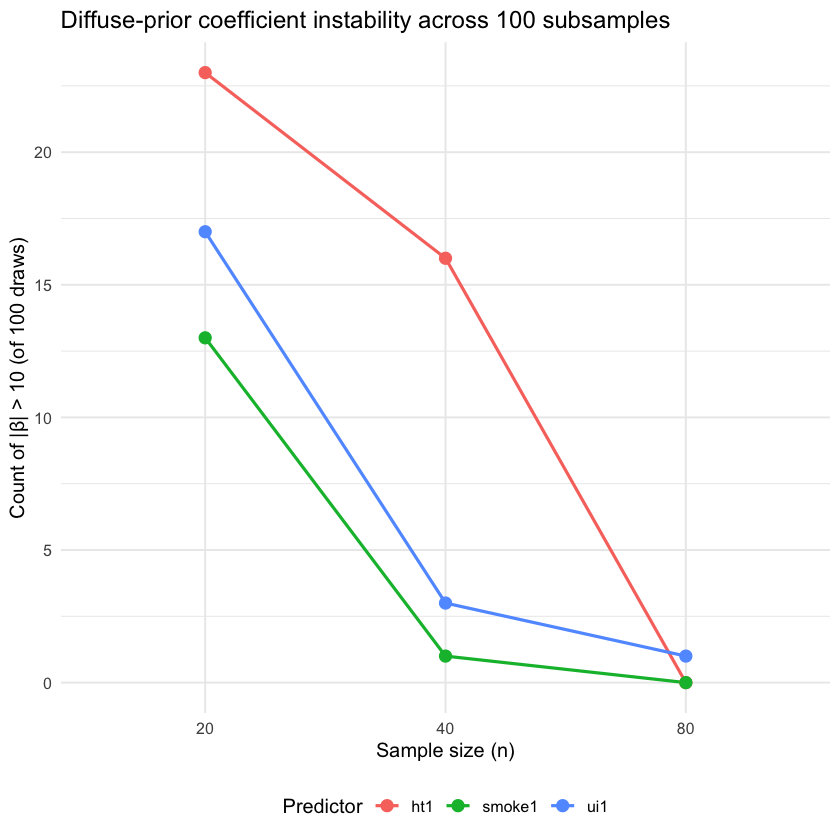

In [37]:
df.rep %>%
  filter(Model == "Diffuse") %>%
  group_by(n, Variable) %>%
  summarise(
    n_explode = sum(exploded[defined], na.rm = TRUE),
    .groups = "drop"
  ) %>%
  ggplot(aes(factor(n), n_explode, color = Variable, group = Variable)) +
  geom_line(linewidth = 0.9) + geom_point(size = 3) +
  labs(title = "Diffuse-prior coefficient instability across 100 subsamples",
     x = "Sample size (n)", 
     y = "Count of |β| > 10 (of 100 draws)", 
     color = "Predictor") +
  theme_minimal(base_size = 12) + theme(legend.position = "bottom")

# Analysis 3: Predictive Performance Across Sample Sizes

## AUC by Sample Size and Prior

In [38]:
print(df.auc, row.names = FALSE)

   n       Model   AUC   LOOIC k_warn
  20     Diffuse 1.000   8.333     20
  20        Weak 0.952  28.086      5
  20 Informative 0.905  27.058      1
  40     Diffuse 0.808  65.343      4
  40        Weak 0.799  61.133      0
  40 Informative 0.750  56.309      1
  80     Diffuse 0.789 105.907      0
  80        Weak 0.785 102.436      1
  80 Informative 0.777  98.220      0
 189     Diffuse 0.746 223.847      0
 189        Weak 0.747 223.324      0
 189 Informative 0.748 220.428      0


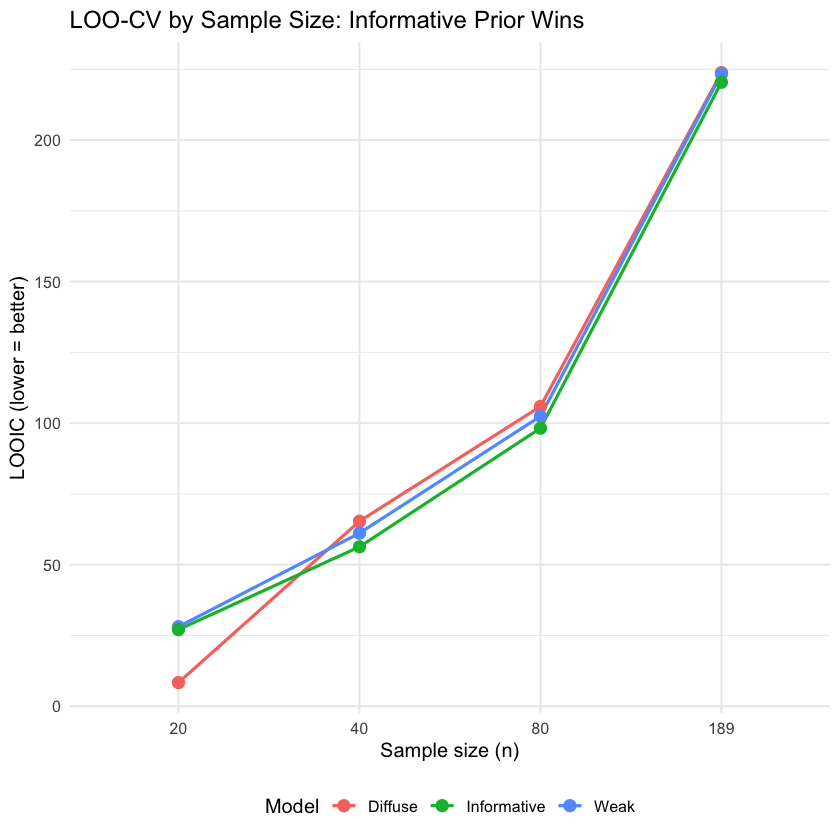

In [39]:
df.auc %>%
  ggplot(aes(factor(n), LOOIC, color = Model, group = Model)) +
  geom_line(linewidth = 0.9) + geom_point(size = 3) +
  labs(title = "LOO-CV by Sample Size: Informative Prior Wins",
       x = "Sample size (n)", y = "LOOIC (lower = better)") +
  theme_minimal(base_size = 12) + theme(legend.position = "bottom")

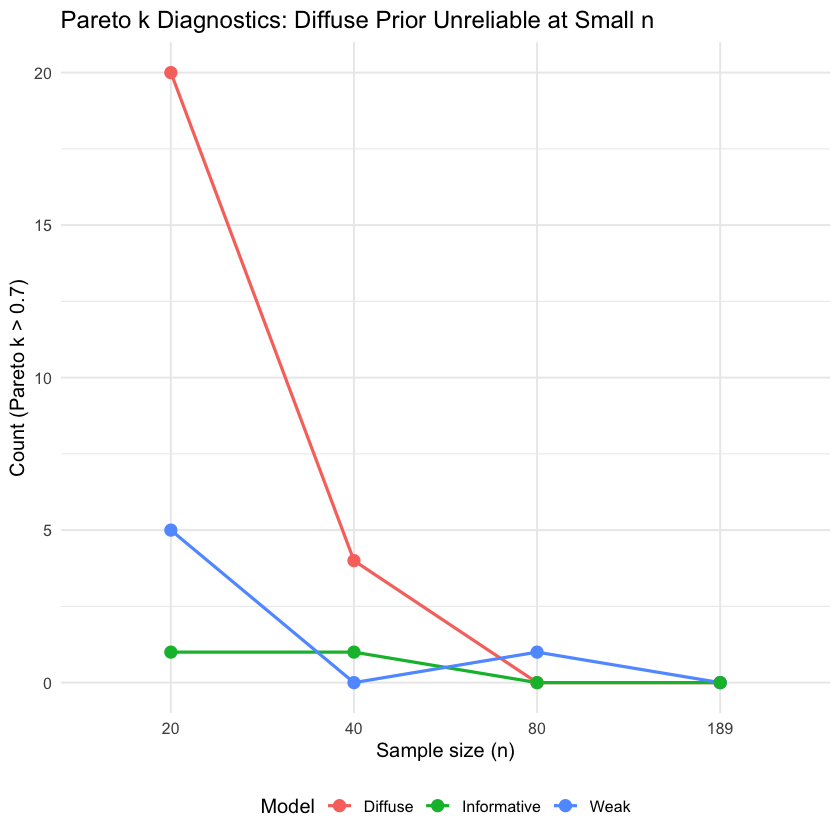

In [40]:
df.auc %>%
  ggplot(aes(factor(n), k_warn, color = Model, group = Model)) +
  geom_line(linewidth = 0.9) + geom_point(size = 3) +
  labs(title = "Pareto k Diagnostics: Diffuse Prior Unreliable at Small n",
       x = "Sample size (n)", y = "Count (Pareto k > 0.7)") +
  theme_minimal(base_size = 12) + theme(legend.position = "bottom")

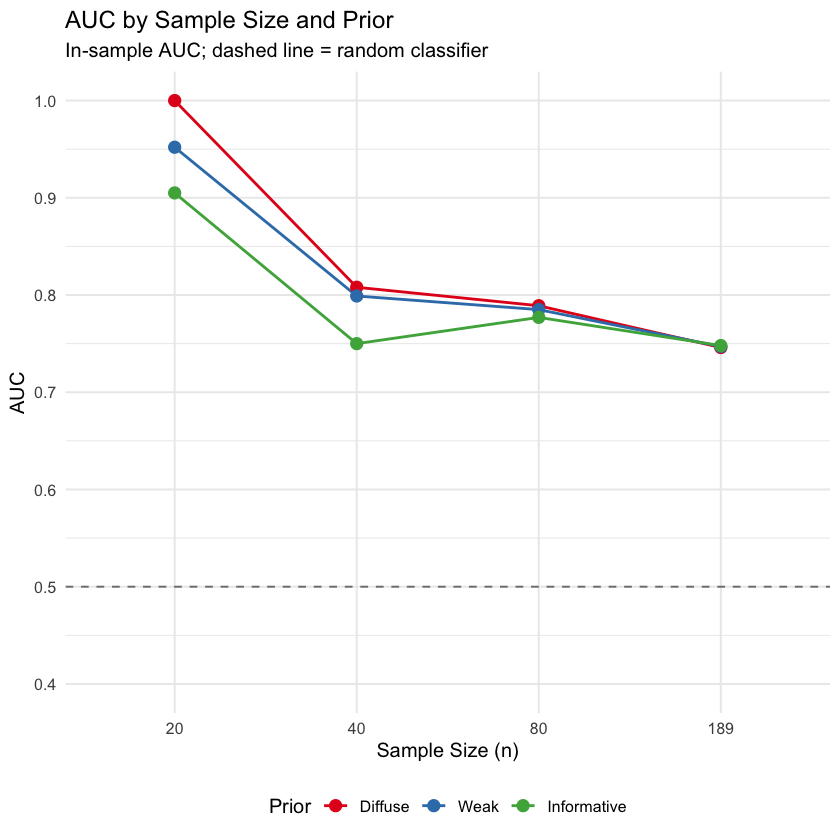

In [41]:
df.auc$Model <- factor(df.auc$Model, levels = c("Diffuse", "Weak", "Informative"))
df.auc$n     <- factor(df.auc$n, levels = c(20, 40, 80, 189))

ggplot(df.auc, aes(x = n, y = AUC, color = Model, group = Model)) +
  geom_line(linewidth = 0.8) +
  geom_point(size = 3) +
  geom_hline(yintercept = 0.5, linetype = "dashed", color = "grey50") +
  scale_color_manual(values = c("Diffuse"     = "#E41A1C",
                                "Weak"        = "#377EB8",
                                "Informative" = "#4DAF4A")) +
  scale_y_continuous(limits = c(0.4, 1.0), breaks = seq(0.4, 1.0, 0.1)) +
  labs(title    = "AUC by Sample Size and Prior",
       subtitle = "In-sample AUC; dashed line = random classifier",
       x = "Sample Size (n)", y = "AUC",
       color = "Prior") +
  theme_minimal(base_size = 12) +
  theme(legend.position = "bottom")

# Export Models

In [42]:
saveRDS(fit.diffuse,     "../models/fit_diffuse.rds")
saveRDS(fit.weak,        "../models/fit_weak.rds")
saveRDS(fit.informative, "../models/fit_informative.rds")
cat("Models saved.\n")

Models saved.
